# Student Career Advisor — Data Preprocessing

**Source:** Stack Overflow Developer Survey 2024 (`results.csv`)  
**Goal:** Build `student_advisor_data.json` — a knowledge base that maps  
developer roles → required skills, so students can ask *'What do I need to become a Data Scientist?'* and get a real, data-driven answer.

---
### Notebook Flow
1. Load raw data
2. Explore & identify problems
3. Clean each problem
4. Build role profiles
5. Visualise
6. Save JSON knowledge base


In [1]:
import pandas as pd
import json
import warnings
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 4)
warnings.filterwarnings('ignore')
print('Libraries loaded OK')


Libraries loaded OK


## Step 1 — Load Raw Data


In [2]:
df_raw = pd.read_csv('results.csv', low_memory=False)
print(f'Rows    : {len(df_raw):,}')
print(f'Columns : {len(df_raw.columns)}')
df_raw.head(2)


Rows    : 49,191
Columns : 172


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0


## Step 2 — Explore & Identify Problems

We run quick audits on the raw data before touching anything.


In [3]:
# 2a. Missing values
missing = df_raw.isnull().mean().sort_values(ascending=False) * 100
print('=== Top 20 columns by % missing ===')
print(missing.head(20).round(1).to_string())


=== Top 20 columns by % missing ===
AIAgentObsWrite         99.5
SOTagsWant Entry        99.1
SOTagsHaveEntry         99.1
AIModelsWantEntry       99.0
AIAgentOrchWrite        99.0
JobSatPoints_15_TEXT    98.7
AIAgentKnowWrite        98.4
AIModelsHaveEntry       98.4
SO_Actions_15_TEXT      98.3
AIAgentExtWrite         98.3
CommPlatformWantEntr    97.6
CommPlatformHaveEntr    97.0
DatabaseWantEntry       96.9
OfficeStackWantEntry    96.7
TechOppose_15_TEXT      96.7
TechEndorse_13_TEXT     95.9
DevEnvWantEntry         95.7
DatabaseHaveEntry       95.6
OfficeStackHaveEntry    94.7
WebframeWantEntry       94.7


In [4]:
# 2b. Show that many columns are semicolon-separated multi-value strings
multi_cols = ['DevType','LanguageHaveWorkedWith','DatabaseHaveWorkedWith',
              'WebframeHaveWorkedWith','PlatformHaveWorkedWith','LearnCode']
print('=== Multi-value columns (raw) ===')
for c in multi_cols:
    sample = df_raw[c].dropna().iloc[0]
    print(f'{c}:\n  {str(sample)[:100]}\n')


=== Multi-value columns (raw) ===
DevType:
  Developer, mobile

LanguageHaveWorkedWith:
  Bash/Shell (all shells);Dart;SQL

DatabaseHaveWorkedWith:
  Cloud Firestore;PostgreSQL

WebframeHaveWorkedWith:
  Spring Boot

PlatformHaveWorkedWith:
  Amazon Web Services (AWS);Cloudflare;Firebase;Google Cloud;Gradle

LearnCode:
  Online Courses or Certification (includes all media types);Other online resources (e.g. standard sea



In [5]:
# 2c. YearsCode has mixed types: strings + numbers
print('YearsCode value counts (top 15):')
print(df_raw['YearsCode'].value_counts().head(15).to_string())


YearsCode value counts (top 15):
YearsCode
10.0    3108
15.0    2540
20.0    2497
5.0     2267
8.0     2113
6.0     1925
25.0    1832
7.0     1820
12.0    1800
30.0    1740
4.0     1602
9.0     1399
3.0     1284
13.0    1171
14.0    1109


In [6]:
# 2d. Salary extreme outliers
sal_raw = pd.to_numeric(df_raw['ConvertedCompYearly'], errors='coerce')
coverage = sal_raw.notna().mean() * 100
print(f'Salary non-null: {sal_raw.notna().sum():,} / {len(df_raw):,} ({coverage:.1f}%)')
print(f'Min salary  : ${sal_raw.min():,.0f}')
print(f'Max salary  : ${sal_raw.max():,.0f}  <-- likely bad data')
print(f'Median      : ${sal_raw.median():,.0f}')
print(f'Rows >$1M/yr: {(sal_raw > 1_000_000).sum()}')


Salary non-null: 23,947 / 49,191 (48.7%)
Min salary  : $1
Max salary  : $50,000,000  <-- likely bad data
Median      : $75,320
Rows >$1M/yr: 46


In [7]:
# 2e. Check if DevType has multiple roles per person (semicolon-separated)
devtype_raw = df_raw['DevType'].dropna()
multi_role = devtype_raw.str.contains(';').sum()
pct = multi_role / len(devtype_raw) * 100
print(f'Total DevType responses : {len(devtype_raw):,}')
print(f'Multi-role rows (with ;): {multi_role:,} ({pct:.1f}%)')
print()
if multi_role > 0:
    print('Example multi-role:', devtype_raw[devtype_raw.str.contains(';')].iloc[0])
else:
    print('Finding: Each respondent has exactly ONE DevType in this dataset.')
    print('Unique roles found:', devtype_raw.nunique())
    print('\nTop 10 roles:')
    print(devtype_raw.value_counts().head(10).to_string())


Total DevType responses : 43,680
Multi-role rows (with ;): 0 (0.0%)

Finding: Each respondent has exactly ONE DevType in this dataset.
Unique roles found: 32

Top 10 roles:
DevType
Developer, full-stack                            12351
Developer, back-end                               6453
Student                                           3008
Architect, software or solutions                  2684
Developer, front-end                              1974
Developer, desktop or enterprise applications     1919
Other (please specify):                           1825
Developer, mobile                                 1391
Developer, embedded applications or devices       1274
Academic researcher                               1131


## Step 3 — Problems Found & Solutions

| # | Problem | Column(s) | Solution |
|---|---------|-----------|----------|
| 1 | **172 columns, only ~14 useful** | All | Select only 14 relevant columns |
| 2 | **High missing values** (up to 80%+) | Many columns | Drop irrelevant columns; use per-role filtering |
| 3 | **Multi-value semicolon strings** | Languages, DBs, Frameworks, Platforms... | Split by `;` into Python lists |
| 4 | **YearsCode mixed types** (`str` + `int`) | YearsCode | `pd.to_numeric(errors='coerce')` — text becomes NaN |
| 5 | **Salary extreme outliers** ($1 to $50M/yr) | ConvertedCompYearly | Cap at $1M/yr; use median not mean |
| 6 | **DevType is single-value per person** | DevType | No split needed; filter rows by exact role match |


## Step 4 — Select Relevant Columns


In [8]:
KEEP = [
    'DevType',
    'LanguageHaveWorkedWith',
    'LanguageWantToWorkWith',
    'DatabaseHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'PlatformHaveWorkedWith',
    'YearsCode',
    'EdLevel',
    'Employment',
    'ConvertedCompYearly',
    'Country',
    'Age',
    'LearnCode',
    'Industry',
]
df = df_raw[KEEP].copy()
print(f'Reduced: {len(df_raw.columns)} columns --> {len(df.columns)} columns')
print(f'Rows   : {len(df):,}')
df.isnull().mean().round(3).mul(100).rename('% missing').to_frame()


Reduced: 172 columns --> 14 columns
Rows   : 49,191


,% missing
DevType,11.2
LanguageHaveWorkedWith,35.6
LanguageWantToWorkWith,45.0
DatabaseHaveWorkedWith,48.1
WebframeHaveWorkedWith,53.3
PlatformHaveWorkedWith,50.7
YearsCode,12.5
EdLevel,2.1
Employment,1.7
ConvertedCompYearly,51.3


## Step 5 — Fix Problem 3: Split Multi-Value Columns

Each semicolon-separated string becomes a Python list.


In [9]:
def split_multi(series):
    """Split semicolon-separated strings into lists; NaN -> empty list."""
    return series.fillna('').apply(
        lambda v: [x.strip() for x in v.split(';') if x.strip()] if v else []
    )

multi_cols = ['DevType','LanguageHaveWorkedWith','LanguageWantToWorkWith',
              'DatabaseHaveWorkedWith','WebframeHaveWorkedWith',
              'PlatformHaveWorkedWith','LearnCode']
for col in multi_cols:
    df[col] = split_multi(df[col])

# Show before vs after
raw_val = df_raw['LanguageHaveWorkedWith'].dropna().iloc[0]
clean_val = df['LanguageHaveWorkedWith'].iloc[0]
print('BEFORE (raw string):')
print(' ', raw_val)
print('\nAFTER (Python list):')
print(' ', clean_val)


BEFORE (raw string):
  Bash/Shell (all shells);Dart;SQL

AFTER (Python list):
  ['Bash/Shell (all shells)', 'Dart', 'SQL']


## Step 6 — Fix Problem 4: YearsCode Mixed Types

Text values like *'Less than 1 year'* and *'More than 50 years'* become `NaN`  
via `pd.to_numeric(errors='coerce')`. We keep valid numeric years.


In [10]:
df['YearsCode'] = pd.to_numeric(df['YearsCode'], errors='coerce')
print('YearsCode after cleaning:')
print(df['YearsCode'].describe().round(1))
print(f'\nNaN (was text / missing): {df["YearsCode"].isna().sum():,}')


YearsCode after cleaning:
count    43042.0
mean        16.6
std         11.8
min          1.0
25%          8.0
50%         14.0
75%         24.0
max        100.0
Name: YearsCode, dtype: float64

NaN (was text / missing): 6,149


## Step 7 — Fix Problem 5: Salary Outliers

We cap salaries at **$1,000,000/yr** — anything above is likely a data entry error  
or a currency-conversion issue in the survey.


In [11]:
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
before_max = df['ConvertedCompYearly'].max()
removed = (df['ConvertedCompYearly'] > 1_000_000).sum()
df.loc[df['ConvertedCompYearly'] > 1_000_000, 'ConvertedCompYearly'] = None
print(f'Outliers removed (>$1M/yr): {removed}')
print(f'Max before : ${before_max:,.0f}')
print(f'Max after  : ${df["ConvertedCompYearly"].max():,.0f}')
print('\nSalary stats after cleaning:')
print(df['ConvertedCompYearly'].describe().round(0))


Outliers removed (>$1M/yr): 46
Max before : $50,000,000
Max after  : $1,000,000

Salary stats after cleaning:
count      23901.0
mean       91603.0
std        84967.0
min            1.0
25%        38000.0
50%        75000.0
75%       120000.0
max      1000000.0
Name: ConvertedCompYearly, dtype: float64


## Step 8 — Build Role Profiles

For each developer role, we:
- Filter respondents who chose that role (a person can have multiple roles)
- Count the most-used languages, databases, frameworks, platforms
- Compute salary statistics and years of experience
- Record education level and employment type


In [12]:
ROLES = {
    'Data scientist'                              : 'Data Scientist',
    'AI/ML engineer'                              : 'AI / ML Engineer',
    'Data engineer'                               : 'Data Engineer',
    'Developer, full-stack'                       : 'Full-Stack Developer',
    'Developer, back-end'                         : 'Back-End Developer',
    'Developer, front-end'                        : 'Front-End Developer',
    'Developer, mobile'                           : 'Mobile Developer',
    'Developer, embedded applications or devices' : 'Embedded / IoT Developer',
    'DevOps engineer or professional'             : 'DevOps Engineer',
    'Cloud infrastructure engineer'               : 'Cloud Engineer',
    'Cybersecurity or InfoSec professional'       : 'Cybersecurity Engineer',
    'Data or business analyst'                    : 'Data / Business Analyst',
    'Database administrator or engineer'          : 'Database Administrator',
    'Developer, game or graphics'                 : 'Game Developer',
    'Developer, desktop or enterprise applications': 'Desktop / Enterprise Developer',
    'Developer, QA or test'                       : 'QA / Test Engineer',
    'UX, Research Ops or UI design professional'  : 'UX / UI Designer',
    'Architect, software or solutions'            : 'Software Architect',
    'Engineering manager'                         : 'Engineering Manager',
}
print(f'Roles to profile: {len(ROLES)}')


Roles to profile: 19


In [13]:
def top_n(counter, n=10):
    return [{'name': k, 'count': v} for k, v in counter.most_common(n)]

role_profiles = {}

for raw_role, display_role in ROLES.items():
    mask = df['DevType'].apply(lambda lst: raw_role in lst)
    sub  = df[mask]
    n    = len(sub)
    if n < 30:
        continue

    def pool(col):
        c = Counter()
        for lst in sub[col]: c.update(lst)
        return c

    sal = sub['ConvertedCompYearly'].dropna()
    exp = sub['YearsCode'].dropna()

    salary_stats = {}
    if len(sal) >= 10:
        salary_stats = {
            'median_usd'  : round(sal.median()),
            'p25_usd'     : round(sal.quantile(0.25)),
            'p75_usd'     : round(sal.quantile(0.75)),
            'sample_size' : len(sal),
        }

    exp_stats = {}
    if len(exp) >= 10:
        exp_stats = {
            'median_years': round(exp.median(), 1),
            'p25_years'   : round(exp.quantile(0.25), 1),
            'p75_years'   : round(exp.quantile(0.75), 1),
        }

    role_profiles[display_role] = {
        'sample_count'      : n,
        'languages'         : top_n(pool('LanguageHaveWorkedWith'), 10),
        'languages_wanted'  : top_n(pool('LanguageWantToWorkWith'), 8),
        'databases'         : top_n(pool('DatabaseHaveWorkedWith'), 8),
        'frameworks'        : top_n(pool('WebframeHaveWorkedWith'), 8),
        'platforms'         : top_n(pool('PlatformHaveWorkedWith'), 8),
        'learning_resources': top_n(pool('LearnCode'), 6),
        'salary'            : salary_stats,
        'experience'        : exp_stats,
        'education'         : sub['EdLevel'].dropna().value_counts().head(5).to_dict(),
        'employment'        : sub['Employment'].dropna().value_counts().head(4).to_dict(),
    }

print(f'Built {len(role_profiles)} role profiles')
print('-' * 55)
for role, p in role_profiles.items():
    print(f"  {p['sample_count']:5,}  respondents  ->  {role}")


Built 19 role profiles
-------------------------------------------------------
    574  respondents  ->  Data Scientist
    677  respondents  ->  AI / ML Engineer
    770  respondents  ->  Data Engineer
  12,351  respondents  ->  Full-Stack Developer
  6,453  respondents  ->  Back-End Developer
  1,974  respondents  ->  Front-End Developer
  1,391  respondents  ->  Mobile Developer
  1,274  respondents  ->  Embedded / IoT Developer
  1,053  respondents  ->  DevOps Engineer
    441  respondents  ->  Cloud Engineer
    370  respondents  ->  Cybersecurity Engineer
    351  respondents  ->  Data / Business Analyst
    175  respondents  ->  Database Administrator
    451  respondents  ->  Game Developer
  1,919  respondents  ->  Desktop / Enterprise Developer
    343  respondents  ->  QA / Test Engineer
    115  respondents  ->  UX / UI Designer
  2,684  respondents  ->  Software Architect
  1,068  respondents  ->  Engineering Manager


## Step 9 — Visualise Top Skills per Role


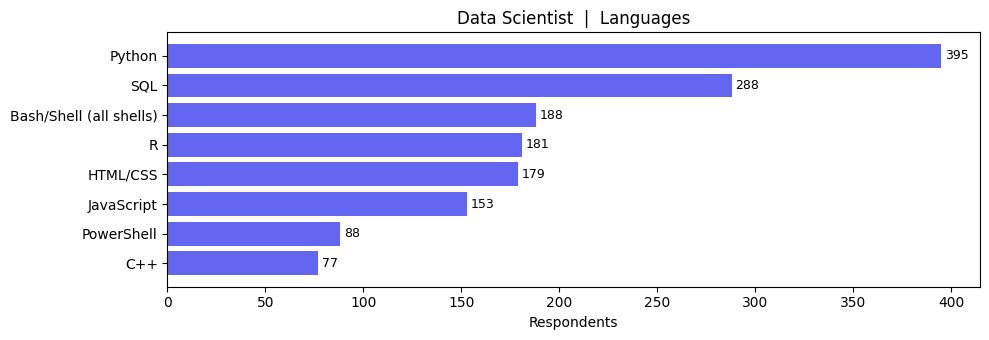

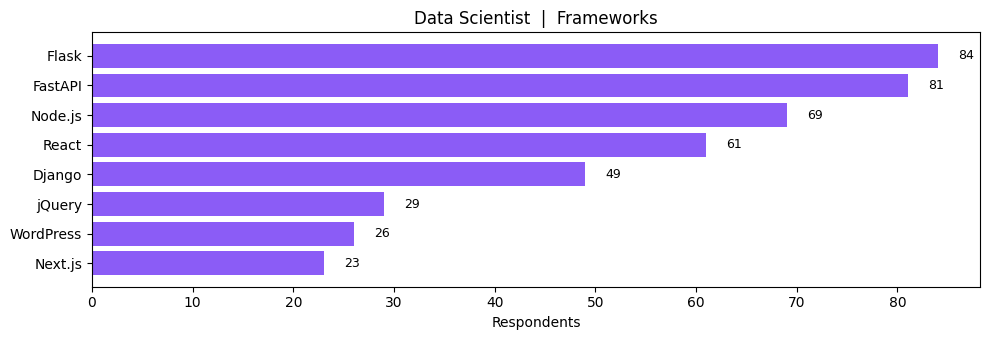

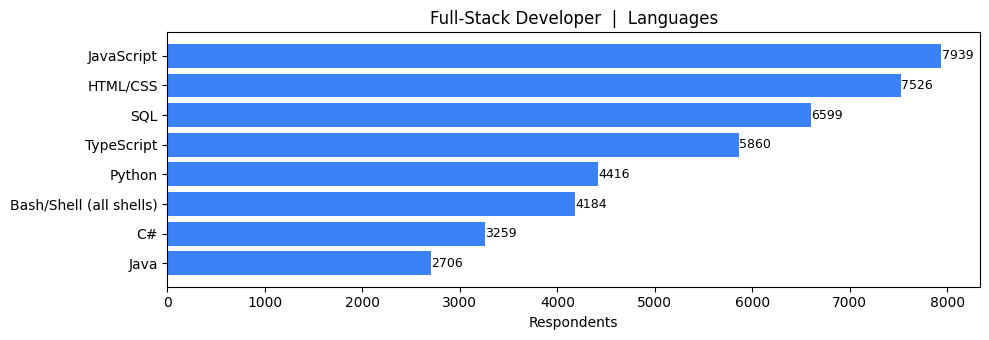

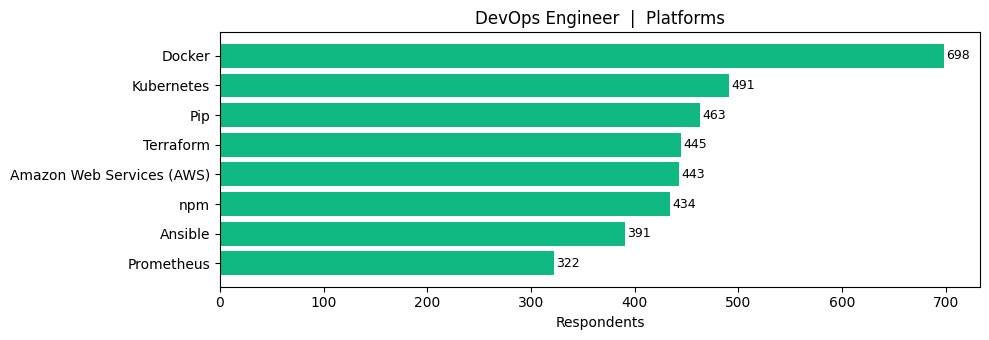

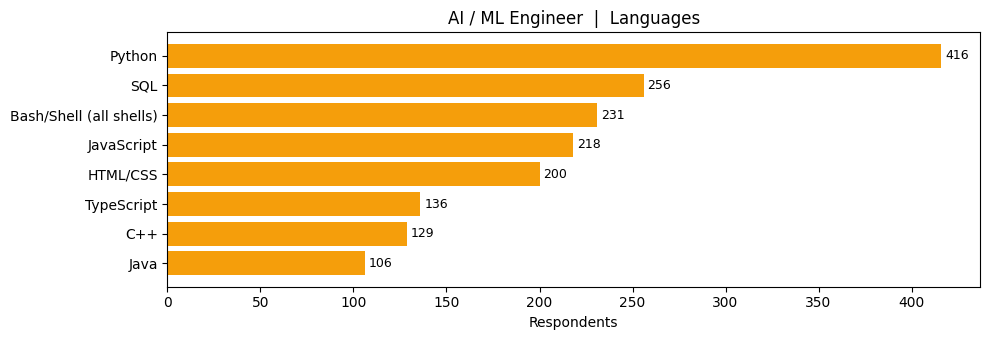

In [14]:
def plot_top_skills(role_name, skill_key='languages', top=8, color='#4F86F7'):
    if role_name not in role_profiles:
        print(f'Role not found: {role_name}'); return
    items  = role_profiles[role_name][skill_key][:top]
    names  = [i['name'] for i in items]
    counts = [i['count'] for i in items]
    fig, ax = plt.subplots(figsize=(10, 3.5))
    bars = ax.barh(names[::-1], counts[::-1], color=color)
    ax.set_xlabel('Respondents')
    ax.set_title(f'{role_name}  |  {skill_key.replace("_"," ").title()}')
    for bar, cnt in zip(bars, counts[::-1]):
        ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
                str(cnt), va='center', fontsize=9)
    plt.tight_layout(); plt.show()

plot_top_skills('Data Scientist',     'languages',   color='#6366f1')
plot_top_skills('Data Scientist',     'frameworks',  color='#8b5cf6')
plot_top_skills('Full-Stack Developer','languages',  color='#3b82f6')
plot_top_skills('DevOps Engineer',    'platforms',   color='#10b981')
plot_top_skills('AI / ML Engineer',   'languages',   color='#f59e0b')


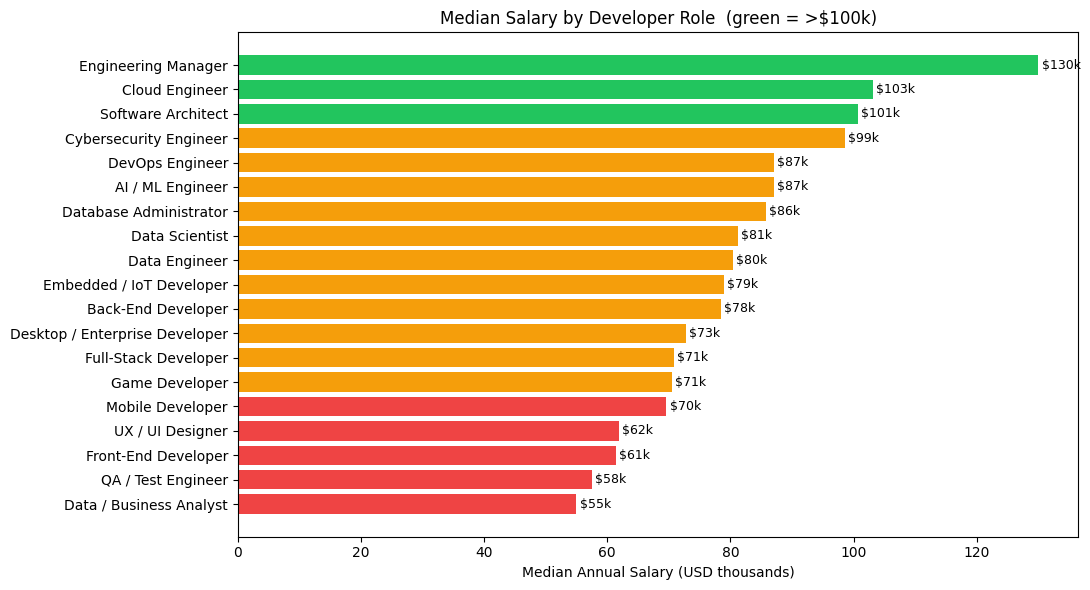

In [15]:
# Salary comparison across all roles
salary_data = [(role, p['salary']['median_usd'])
               for role, p in role_profiles.items() if p.get('salary')]
salary_data.sort(key=lambda x: x[1])
roles_s, medians = zip(*salary_data)

fig, ax = plt.subplots(figsize=(11, 6))
colors  = ['#22c55e' if m >= 100000 else '#f59e0b' if m >= 70000 else '#ef4444'
           for m in medians]
bars = ax.barh(roles_s, [m/1000 for m in medians], color=colors)
ax.set_xlabel('Median Annual Salary (USD thousands)')
ax.set_title('Median Salary by Developer Role  (green = >$100k)')
for bar, val in zip(bars, [m/1000 for m in medians]):
    ax.text(bar.get_width()+0.5,
            bar.get_y()+bar.get_height()/2,
            f'${val:.0f}k', va='center', fontsize=9)
plt.tight_layout(); plt.show()


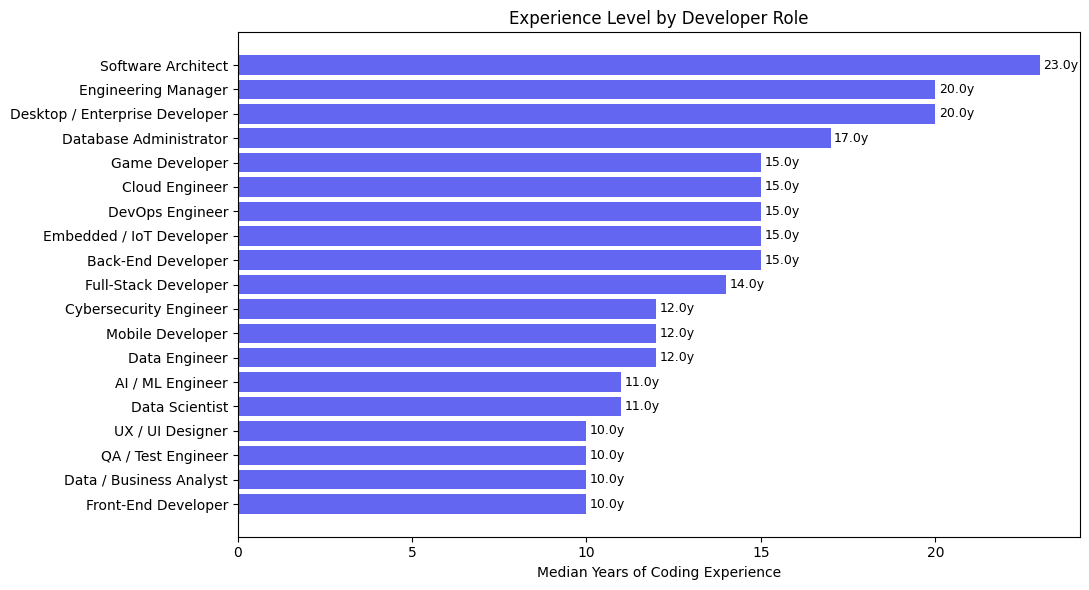

In [16]:
# Years of experience comparison
exp_data = [(role, p['experience']['median_years'])
            for role, p in role_profiles.items() if p.get('experience')]
exp_data.sort(key=lambda x: x[1])
roles_e, exps = zip(*exp_data)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(roles_e, exps, color='#6366f1')
ax.set_xlabel('Median Years of Coding Experience')
ax.set_title('Experience Level by Developer Role')
for i, (val, role) in enumerate(zip(exps, roles_e)):
    ax.text(val+0.1, i, f'{val}y', va='center', fontsize=9)
plt.tight_layout(); plt.show()


## Step 10 — Global Stats & Role Aliases


In [17]:
all_langs = Counter()
for lst in df['LanguageHaveWorkedWith']: all_langs.update(lst)
all_dbs = Counter()
for lst in df['DatabaseHaveWorkedWith']: all_dbs.update(lst)
all_fws = Counter()
for lst in df['WebframeHaveWorkedWith']: all_fws.update(lst)

global_stats = {
    'total_respondents'      : len(df),
    'top_languages_overall'  : top_n(all_langs, 15),
    'top_databases_overall'  : top_n(all_dbs, 15),
    'top_frameworks_overall' : top_n(all_fws, 15),
}

ALIASES = {
    'data scientist':'Data Scientist', 'data science':'Data Scientist',
    'machine learning':'AI / ML Engineer', 'ml engineer':'AI / ML Engineer',
    'ai engineer':'AI / ML Engineer', 'deep learning':'AI / ML Engineer',
    'data engineer':'Data Engineer', 'etl':'Data Engineer',
    'analyst':'Data / Business Analyst', 'business analyst':'Data / Business Analyst',
    'full stack':'Full-Stack Developer', 'fullstack':'Full-Stack Developer',
    'backend':'Back-End Developer', 'back end':'Back-End Developer',
    'frontend':'Front-End Developer', 'front end':'Front-End Developer',
    'web developer':'Full-Stack Developer',
    'mobile':'Mobile Developer', 'android':'Mobile Developer',
    'ios':'Mobile Developer', 'flutter':'Mobile Developer',
    'devops':'DevOps Engineer', 'sre':'DevOps Engineer',
    'cloud':'Cloud Engineer', 'aws':'Cloud Engineer', 'azure':'Cloud Engineer',
    'security':'Cybersecurity Engineer', 'cybersecurity':'Cybersecurity Engineer',
    'game':'Game Developer', 'unity':'Game Developer', 'unreal':'Game Developer',
    'qa':'QA / Test Engineer', 'testing':'QA / Test Engineer',
    'ux':'UX / UI Designer', 'designer':'UX / UI Designer',
    'dba':'Database Administrator',
    'embedded':'Embedded / IoT Developer', 'iot':'Embedded / IoT Developer',
    'architect':'Software Architect', 'manager':'Engineering Manager',
}
print(f'Global stats done. Aliases defined: {len(ALIASES)}')


Global stats done. Aliases defined: 40


## Step 11 — Save Knowledge Base


In [18]:
output = {
    'meta': {
        'source'     : 'Stack Overflow Developer Survey 2024',
        'total_rows' : len(df),
        'roles_count': len(role_profiles),
    },
    'global_stats' : global_stats,
    'role_profiles': role_profiles,
    'role_aliases' : ALIASES,
}
with open('student_advisor_data.json', 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

import os
size_kb = os.path.getsize('student_advisor_data.json') / 1024
print(f'Saved: student_advisor_data.json  ({size_kb:.1f} KB)')
print(f'Roles: {len(role_profiles)}')


Saved: student_advisor_data.json  (99.5 KB)
Roles: 19


In [19]:
# Quick sanity check
print('=== Data Scientist ===')
ds = role_profiles['Data Scientist']
print(f"Respondents : {ds['sample_count']:,}")
print(f"Median Salary: ${ds['salary']['median_usd']:,}/yr")
print(f"Median Exp   : {ds['experience']['median_years']} years")
print('Top languages:', [x['name'] for x in ds['languages'][:5]])
print('Top databases:', [x['name'] for x in ds['databases'][:4]])
print('Top frameworks:', [x['name'] for x in ds['frameworks'][:4]])


=== Data Scientist ===
Respondents : 574
Median Salary: $81,210/yr
Median Exp   : 11.0 years
Top languages: ['Python', 'SQL', 'Bash/Shell (all shells)', 'R', 'HTML/CSS']
Top databases: ['PostgreSQL', 'SQLite', 'MySQL', 'Microsoft SQL Server']
Top frameworks: ['Flask', 'FastAPI', 'Node.js', 'React']


---
## Done!

The file `student_advisor_data.json` is now ready.  
It contains **role profiles** for 19 developer careers — each with:
- Top languages, databases, frameworks, platforms
- Salary range (25th / median / 75th percentile)
- Years of experience
- Education level & employment type
- Learning resource preferences

This JSON feeds the **Student Career Advisor** chatbot.
